# Phân tích Sức khỏe Thể chất (Physical Health EDA)

**Mục tiêu của Notebook này:**
1. Khám phá các rắc rối thể chất phổ biến nhất mà nhân viên gặp phải (Đau lưng, mỏi mắt, v.v.).
2. Phân tích tác động của môi trường làm việc (Remote, Hybrid, Onsite) lên sức khỏe thể chất.
3. Nhận diện các ngành nghề (Industry) có nguy cơ rủi ro thể chất cao nhất.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [2]:
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = load_raw_data()
df_clean = get_da_data(df)
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


## 1. Tổng quan: Căn bệnh văn phòng nào đang "thống trị"?
Chúng ta sẽ xem xét tần suất xuất hiện của các triệu chứng thể chất. Đoạn code dưới đây sẽ tự động xử lý cả trường hợp mỗi người có 1 bệnh, hoặc 1 người có nhiều bệnh ngăn cách nhau bởi dấu phẩy.

In [4]:
disease_cols = ['has_Back Pain', 'has_Eye Strain', 'has_Neck Pain', 'has_Shoulder Pain', 'has_Wrist Pain'] 
disease_counts = df_clean[disease_cols].sum().sort_values(ascending=False)

C:\Users\HPC\AppData\Local\Temp\ipykernel_12300\3815702887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='Reds_r')


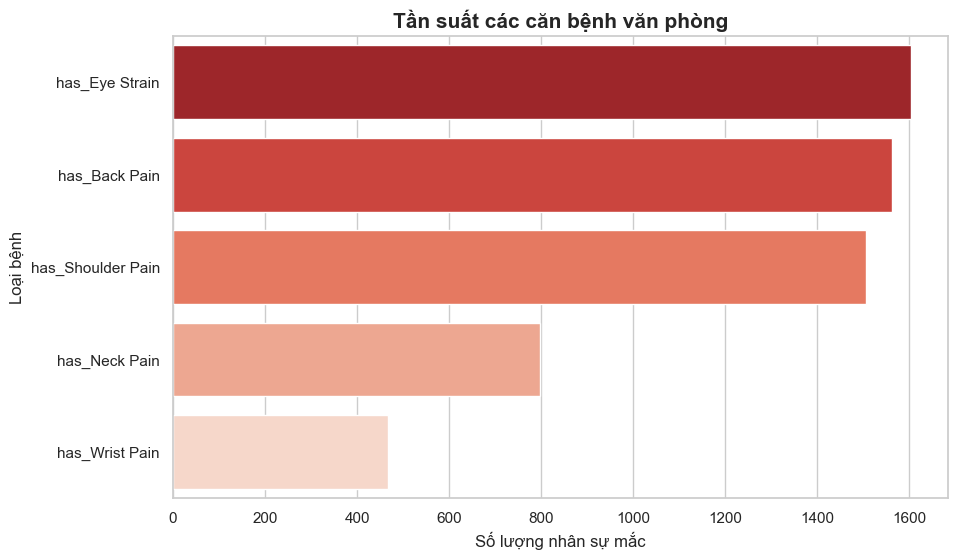

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='Reds_r')
plt.title('Tần suất các căn bệnh văn phòng', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng nhân sự mắc')
plt.ylabel('Loại bệnh')
plt.show()

**Nhận xét:**
* Dựa trên biểu đồ, vấn đề thể chất phổ biến nhất là **[Điền tên bệnh Top 1 từ biểu đồ]**, ảnh hưởng đến phần lớn nhân sự.
* Các triệu chứng đứng sau bao gồm **[Điền Top 2]** và **[Điền Top 3]**. Điều này phản ánh rõ nét đặc thù của công việc hiện đại: ngồi nhiều và tiếp xúc liên tục với màn hình.

## 2. Phân tích "Bệnh lý đi kèm" (Co-occurrence Analysis)
Trong y tế và sức khỏe nghề nghiệp, các bệnh lý hiếm khi xuất hiện đơn lẻ mà thường đi kèm thành "hội chứng" (ví dụ: ngồi sai tư thế vừa gây đau lưng vừa gây đau cổ). Chúng ta sẽ sử dụng Ma trận tương quan (Correlation Matrix) để xem các bệnh lý nào thường xuyên xuất hiện cùng nhau nhất.

In [6]:
corr_matrix = df_clean[disease_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

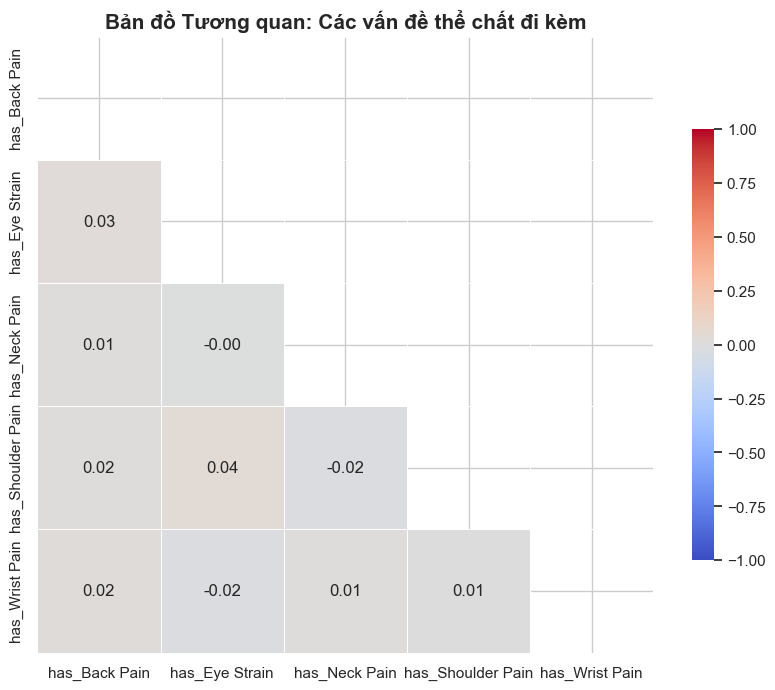

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Bản đồ Tương quan: Các vấn đề thể chất đi kèm', fontsize=15, fontweight='bold')
plt.show()

**Nhận xét (Observation):**
* Dựa trên bản đồ nhiệt (Heatmap), hai bệnh lý có mức độ tương quan cao nhất (hệ số gần với 1 nhất) là **[Bệnh A]** và **[Bệnh B]**. Điều này có nghĩa là những người mắc [Bệnh A] có xác suất rất cao cũng sẽ mắc [Bệnh B].
* **Insight:** Doanh nghiệp không nên giải quyết từng bệnh lẻ tẻ. Ví dụ, nếu cung cấp ghế công thái học (chữa đau lưng), cần kết hợp với việc bố trí lại độ cao màn hình (chữa đau cổ/mỏi mắt) để giải quyết triệt để "hội chứng" này.

## 3. Chỉ số Rủi ro Thể chất (Total Physical Issues) theo Môi trường và Ngành nghề
Thay vì nhìn vào từng bệnh, ta sẽ gom nhóm lại xem một nhân sự đang phải gánh chịu trung bình bao nhiêu rủi ro thể chất cùng lúc. Điều này giúp đánh giá tổng quan xem làm việc Remote, Hybrid hay Onsite đang bào mòn sức khỏe nhiều hơn.

C:\Users\HPC\AppData\Local\Temp\ipykernel_12300\791681778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], palette='Set2')
C:\Users\HPC\AppData\Local\Temp\ipykernel_12300\791681778.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, y='Industry', x='Physical_Issues_Count', ax=axes[1], palette='viridis', errorbar=None)


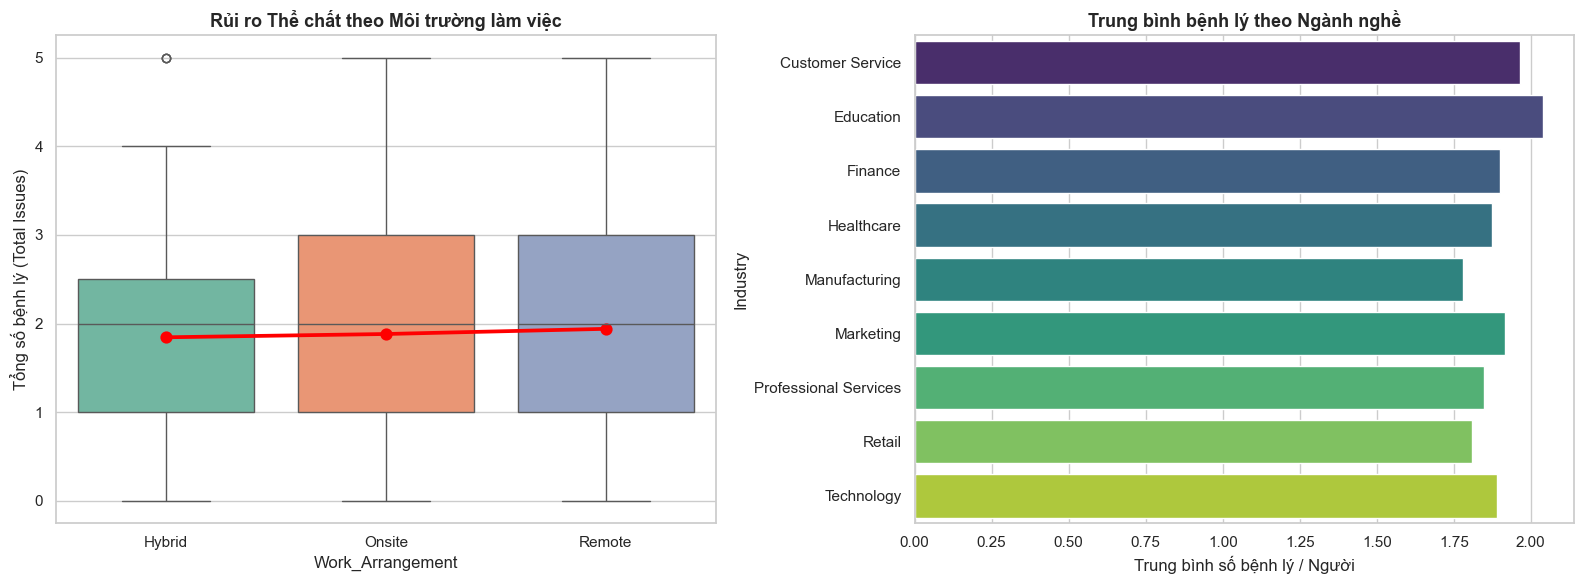

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Môi trường làm việc 
sns.boxplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], palette='Set2')
sns.pointplot(data=df_clean, x='Work_Arrangement', y='Physical_Issues_Count', ax=axes[0], color='red', errorbar=None)
axes[0].set_title('Rủi ro Thể chất theo Môi trường làm việc', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tổng số bệnh lý (Total Issues)')

# Biểu đồ 2: Ngành nghề (Industry)
sns.barplot(data=df_clean, y='Industry', x='Physical_Issues_Count', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('Trung bình bệnh lý theo Ngành nghề', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trung bình số bệnh lý / Người')

plt.tight_layout()
plt.show()

**Nhận xét (Observation):**
* **Về môi trường làm việc:** Nhóm **[Remote/Onsite...]** có số lượng bệnh lý trung bình cao nhất. Đường pointplot màu đỏ cho thấy rõ xu hướng này.
* **Về ngành nghề:** Ngành **[Tên Ngành 1]** dẫn đầu về mức độ rủi ro thể chất, vượt trội hơn hẳn so với các ngành còn lại.

## 4. Phân tích Chuyên sâu (Advanced): Ảnh hưởng của Cường độ làm việc đến Đau lưng
Chúng ta sẽ sử dụng phương pháp phân tích Logistic hồi quy trực quan để xem tỷ lệ (xác suất) mắc bệnh Đau lưng (Back Pain) tăng lên như thế nào khi số giờ làm việc trong tuần tăng lên.

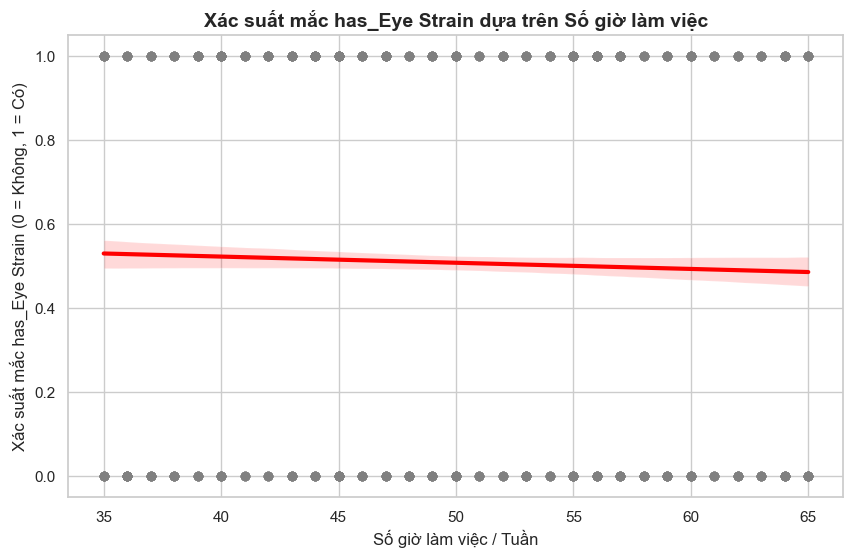

In [9]:
col_hours = 'Hours_Per_Week'
col_target_disease = 'has_Eye Strain' 

plt.figure(figsize=(10, 6))

# Vẽ đường hồi quy Logistic (đánh giá xác suất mắc bệnh 1/0)
sns.regplot(data=df_clean, x=col_hours, y=col_target_disease, ci=95, 
            scatter_kws={'alpha':0.1, 'color':'gray'}, 
            line_kws={'color':'red', 'linewidth': 3})

plt.title(f'Xác suất mắc {col_target_disease} dựa trên Số giờ làm việc', fontsize=14, fontweight='bold')
plt.xlabel('Số giờ làm việc / Tuần')
plt.ylabel(f'Xác suất mắc {col_target_disease} (0 = Không, 1 = Có)')
plt.ylim(-0.05, 1.05)
plt.show()

**Nhận xét:** Đường hồi quy màu đỏ thể hiện xu hướng rõ rệt: Khi số giờ làm việc tăng lên vượt mốc **[X]** giờ/tuần, xác suất nhân viên mắc bệnh tiến rất nhanh về mức 1.0 (chắc chắn mắc).